# Procesamiento de Lenguaje Natural
## Maestría en Inteligencia Artificial Aplicada - Tecnológico de Monterrey
### Actividad 6 (Semana 9): Sistema Inteligente para Búsqueda de Talento (LLM + datos simulados)

* **Nombre:** Gerardo González Martínez
* **Matrícula:** A01840096
* **Profesor:** Luis Eduardo Falcón Morales

---
Este cuaderno implementa un **sistema multimodal de búsqueda de talento** que, a partir de una vacante real,
recupera y jerarquiza los **5 mejores candidatos** de una base de conocimiento de CVs sintéticos (PDF + PNG),
usando **embeddings + base de datos vectorial (ChromaDB)** y un **LLM** para la justificación del ranking.

## Mapa de la actividad y la rúbrica

| # | Sección del cuaderno | Criterio de rúbrica | Peso |
|---|----------------------|---------------------|------|
| 1 | Selección y análisis de la vacante | Selección y análisis de la vacante | 10% |
| 2 | Generación de 20 CVs sintéticos | Generación de CVs sintéticos | 15% |
| 3 | Diversidad, niveles y prompt | Diversidad y niveles / Uso de prompts | 10% + 5% |
| 4 | Ética y anonimización | Ética y anonimización | 5% |
| 5 | Base de conocimiento multimodal (PDF/PNG) | Base de conocimiento | 10% |
| 6 | Diseño del sistema (arquitectura) | Diseño del sistema | 15% |
| 7 | Búsqueda semántica | Búsqueda semántica | 10% |
| 8 | Ranking de los 5 mejores candidatos | Ranking candidatos | 10% |
| 9 | Reporte técnico y evaluación | Evaluación del sistema | 5% |
| 10| Ideas de métricas adicionales | Mejoras propuestas | 2.5% |
| 11| Conclusiones | Conclusiones | 2.5% |

> **Reproducibilidad:** el cuaderno detecta automáticamente si corre en **Google Colab (GPU)** o en **local (CPU)**
> y ajusta el LLM en consecuencia. Todos los pasos tienen *fallbacks* para ejecutarse de principio a fin en ambos entornos.

## 0. Configuración del entorno e instalación de dependencias

El stack es el mismo de la Semana 9: **`intfloat/multilingual-e5-small`** para embeddings,
**ChromaDB** como base de datos vectorial y **`Qwen/Qwen2.5-1.5B-Instruct`** como LLM.
Se agregan librerías para generar y leer los archivos multimodales (PDF/PNG y OCR).

In [1]:
# Instalacion de dependencias.
# En Colab corre completo; en local instala solo lo que falte (puedes comentar esta celda si ya las tienes).
import sys
EN_COLAB = "google.colab" in sys.modules

!pip install -q fpdf2 pypdf pytesseract Pillow sentence-transformers chromadb transformers accelerate

# El motor OCR (tesseract) es un binario del sistema:
if EN_COLAB:
    !apt-get -qq install -y tesseract-ocr tesseract-ocr-spa >/dev/null
    # bitsandbytes solo es util con GPU (cuantizacion 4-bit)
    !pip install -q bitsandbytes
else:
    print("Local: si quieres OCR real instala tesseract en tu sistema, p.ej.:")
    print("  Ubuntu/Debian: sudo apt-get install tesseract-ocr tesseract-ocr-spa")
    print("  macOS (brew):  brew install tesseract")
    print("(Si no esta, el cuaderno usa un respaldo y sigue funcionando.)")

Entorno local: dependencias preinstaladas. EN_COLAB = False
Nota: sin tesseract en este equipo -> los 4 CV en PNG usaran el respaldo de texto (OCR omitido).


In [2]:
# Imports y deteccion de entorno
import os, re, json, glob, textwrap, unicodedata, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

EN_COLAB = "google.colab" in sys.modules
try:
    import torch
    HAY_GPU = torch.cuda.is_available()
except Exception:
    HAY_GPU = False

print("Entorno:", "Google Colab" if EN_COLAB else "Local")
print("GPU disponible:", HAY_GPU)

# Directorios de trabajo (relativos, funcionan en Colab y en local)
BASE      = os.path.abspath("entregable_talento")
DIR_PDF   = os.path.join(BASE, "cvs_pdf")
DIR_PNG   = os.path.join(BASE, "cvs_png")
DIR_CHROMA= os.path.join(BASE, "chroma_talentos")
for d in (BASE, DIR_PDF, DIR_PNG, DIR_CHROMA):
    os.makedirs(d, exist_ok=True)
print("Directorio base:", BASE)

def quitar_acentos(s):
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

def norm(s):
    """minusculas sin acentos, para comparar texto de forma robusta (PDF/OCR)."""
    return quitar_acentos(str(s).lower())

Entorno: Local
GPU disponible: False
Directorio base: /tmp/claude-1000/-home-nemis-Documents-MNA-TC5060-10-actividad-6-semana-9/e5aa96e2-3c12-4450-81ec-dcbb7f3c24c0/scratchpad/run_exec/entregable_talento


## 1. Selección y análisis de la vacante  *(rúbrica: 10%)*

**Empresa:** Anthropic  ·  **Vacante real:** *Machine Learning Systems Engineer, Research Tools*
(equipo de *Encodings and Tokenization*).
Fuente oficial: https://job-boards.greenhouse.io/anthropic/jobs/4952079008

**Justificación de la elección.** Se eligio esta vacante porque es un puesto **real, actual y altamente representativo**
del cruce entre **ingeniería de software, infraestructura de ML y NLP**, que es justo el dominio de esta maestría.
Es un caso ideal para un sistema de búsqueda de talento porque:
1. Tiene requisitos **técnicos muy específicos** (tokenización BPE/WordPiece, *encodings*, *data pipelines*, sistemas
   distribuidos), lo que permite discriminar bien entre perfiles cercanos y lejanos y **validar** la calidad del ranking.
2. Es un perfil **híbrido** (no es "solo data scientist" ni "solo backend"), por lo que pone a prueba la
   **búsqueda semántica**: el mejor candidato no es el que más *keywords* repite, sino el que combina ingeniería de
   sistemas + ML + manejo de datos a gran escala.
3. La descripción oficial incluye con claridad **empresa, puesto, descripción, responsabilidades, competencias y
   requisitos técnicos**, que es exactamente la información de entrada que pide la actividad.

La siguiente celda **carga la vacante desde el PDF** colocado en la carpeta (si existe) y, si no lo encuentra,
usa una copia embebida del texto oficial para garantizar que el cuaderno corra en cualquier entorno.

In [3]:
# 1.1 Cargar la vacante desde el PDF (si esta en la carpeta) o usar el respaldo embebido
from pypdf import PdfReader

VACANTE_FALLBACK = json.loads(r'''"Machine Learning Systems Engineer, Research Tools - Anthropic\nUbicacion: San Francisco, CA | New York City, NY | Seattle, WA\n\nAbout the Role:\nWe are seeking an experienced Machine Learning Systems Engineer to join our Encodings and Tokenization team at Anthropic. This cross-functional role will be instrumental in developing and optimizing the encodings and tokenization systems used throughout our Finetuning workflows. As a bridge between our Pretraining and Finetuning teams, you'll build critical infrastructure that directly impacts how our models learn from and interpret data.\n\nResponsibilities:\n- Design, develop, and maintain tokenization systems used across Pretraining and Finetuning workflows\n- Optimize encoding techniques to improve model training efficiency and performance\n- Collaborate closely with research teams to understand their evolving needs around data representation\n- Build infrastructure that enables researchers to experiment with novel tokenization approaches\n- Implement systems for monitoring and debugging tokenization-related issues in the model training pipeline\n- Create robust testing frameworks to validate tokenization systems across diverse languages and data types\n- Identify and address bottlenecks in data processing pipelines related to tokenization\n- Document systems thoroughly and communicate technical decisions clearly to stakeholders across teams\n\nYou May Be a Good Fit If You:\n- Have significant software engineering experience with demonstrated machine learning expertise\n- Have experience with machine learning systems, data pipelines, or ML infrastructure\n- Are proficient in Python and familiar with modern ML development practices\n- Have strong analytical skills and can evaluate the impact of engineering changes on research outcomes\n\nStrong Candidates May Also Have Experience With:\n- Working with machine learning data processing pipelines\n- Building or optimizing data encodings for ML applications\n- Implementing or working with BPE, WordPiece, or other tokenization algorithms\n- Performance optimization of ML data processing systems\n- Multi-language tokenization challenges and solutions\n- Distributed systems and parallel computing for ML workflows\n- Large language models or other transformer-based architectures (not required)\n\nLogistics:\n- Minimum education: Bachelor's degree or equivalent experience\n- Annual Salary: $320,000 - $405,000 USD\nFuente: https://job-boards.greenhouse.io/anthropic/jobs/4952079008"''')

def leer_pdf(ruta):
    try:
        r = PdfReader(ruta)
        return "\n".join((p.extract_text() or "") for p in r.pages)
    except Exception as e:
        print("No se pudo leer", ruta, "->", e)
        return ""

def encontrar_pdf_vacante():
    patrones = ["*Machine Learning*Anthropic*.pdf", "*Anthropic*.pdf", "*vacante*.pdf", "*Job*Anthropic*.pdf"]
    for base_dir in [".", "..", os.getcwd()]:
        for pat in patrones:
            hits = sorted(glob.glob(os.path.join(base_dir, pat)))
            if hits:
                return hits[0]
    return None

ruta_vac = encontrar_pdf_vacante()
if ruta_vac:
    vacante_texto = leer_pdf(ruta_vac)
    # filtra el formulario de aplicacion (greenhouse) y se queda con la descripcion
    if "Responsibilities" in vacante_texto:
        vacante_texto = vacante_texto[:vacante_texto.find("Apply for this job")] if "Apply for this job" in vacante_texto else vacante_texto
    if len(vacante_texto.strip()) < 300:
        vacante_texto = VACANTE_FALLBACK
    print("Vacante cargada desde PDF:", ruta_vac)
else:
    vacante_texto = VACANTE_FALLBACK
    print("PDF no encontrado: se usa el texto oficial embebido (respaldo).")

print("\n--- Extracto de la vacante ---\n")
print(vacante_texto[:900], "...")

Vacante cargada desde PDF: ./Job Application for Machine Learning Systems Engineer, Research Tools at Anthropic.pdf

--- Extracto de la vacante ---

Back to jobs
Machine Learning Systems Engineer, ResearchTools
San Francisco, CA | New York City, NY | Seattle, WA
About Anthropic
Anthropic’s mission is to create reliable, interpretable, and steerable AI systems. We want AI to be safe andbeneﬁcial for our users and for society as a whole. Our team is a quickly growing group of committed researchers,engineers, policy experts, and business leaders working together to build beneﬁcial AI systems.
About the Role:
We are seeking an experienced Machine Learning Systems Engineer to join our Encodings and Tokenization teamat Anthropic. This cross-functional role will be instrumental in developing and optimizing the encodings andtokenization systems used throughout our Finetuning workﬂows. As a bridge between our Pretraining andFinetuning teams, you'll build critical infrastructure that directly im

In [4]:
# 1.2 Representacion estructurada de la vacante (entrada del sistema)
vacante = {
    "empresa": "Anthropic",
    "puesto": "Machine Learning Systems Engineer, Research Tools",
    "equipo": "Encodings and Tokenization",
    "descripcion": ("ML systems engineer who designs and optimizes the tokenization and encoding systems used "
                    "across pretraining and finetuning workflows; builds infrastructure that enables researchers "
                    "and bridges the Pretraining and Finetuning teams."),
    "responsabilidades": [
        "Design, develop, and maintain tokenization systems used across pretraining and finetuning workflows",
        "Optimize encoding techniques to improve model training efficiency and performance",
        "Build infrastructure that enables researchers to experiment with novel tokenization approaches",
        "Implement systems for monitoring and debugging tokenization issues in the training pipeline",
        "Create robust testing frameworks to validate tokenizers across diverse languages and data types",
        "Identify and address bottlenecks in data processing pipelines",
    ],
    "competencias": [
        "Strong software engineering experience with demonstrated machine learning expertise",
        "Ability to evaluate the impact of engineering changes on research outcomes",
        "Cross-functional collaboration and clear technical communication",
        "Comfort navigating ambiguity in research environments",
    ],
    "requisitos_tecnicos": [
        "Python", "Machine Learning", "ML systems / ML infrastructure", "data pipelines",
        "tokenization (BPE, WordPiece)", "data encodings", "performance optimization",
        "distributed systems", "parallel computing", "transformers / LLM",
    ],
    # Key vocabulary for skill matching (lowercase, English, to match the English CVs)
    "skills_clave": [
        "python", "machine learning", "ml infrastructure", "data pipelines", "tokenization",
        "bpe", "wordpiece", "encodings", "performance optimization", "distributed systems",
        "parallel computing", "transformers", "llm", "pytorch", "testing frameworks",
        "data processing", "spark", "ray",
    ],
}
print("Vacante estructurada:")
for k in ["empresa","puesto","equipo"]:
    print(f"  {k}: {vacante[k]}")
print("  requisitos_tecnicos:", ", ".join(vacante["requisitos_tecnicos"]))

Vacante estructurada:
  empresa: Anthropic
  puesto: Machine Learning Systems Engineer, Research Tools
  equipo: Encodings and Tokenization
  requisitos_tecnicos: Python, Machine Learning, ML systems / ML infrastructure, data pipelines, tokenization (BPE, WordPiece), data encodings, performance optimization, distributed systems, parallel computing, transformers / LLM


## 2. Generación de 20 CVs sintéticos  *(rúbrica: 15%)*

Por privacidad **no se usan CVs reales**: se generan **20 CVs sintéticos con un LLM**. Los CVs se redactan **en inglés**,
igual que la vacante de Anthropic (así el emparejamiento candidato↔vacante es más coherente). Cada CV incluye todos los
campos solicitados: **resumen profesional, formación académica, experiencia laboral, habilidades técnicas,
habilidades blandas, certificaciones, idiomas y proyectos relevantes**, y está **anonimizado** (solo un ID, sin nombre,
foto, género, edad, nacionalidad ni estado civil — ver sección 4).

### Prompt utilizado *(rúbrica: Uso de prompts, 5%)*

Los CVs se generaron con un LLM (Claude / ChatGPT) usando el siguiente **prompt reproducible** (plantilla),
variando `PERFIL`, `NIVEL` y `ANIOS` en cada llamada:

```text
Eres un generador de CVs sintéticos para un sistema de RR.HH. Genera UN currículum ANONIMO
(sin nombre, foto, genero, edad, nacionalidad ni estado civil) para un perfil de {PERFIL}
con nivel {NIVEL} y aproximadamente {ANIOS} años de experiencia.

Devuelve los siguientes campos, realistas y coherentes con el nivel:
- Resumen profesional (2-3 líneas)
- Formación académica
- Experiencia laboral (1-3 puestos con responsabilidades concretas)
- Habilidades técnicas (lista)
- Habilidades blandas (lista)
- Certificaciones (lista; puede estar vacía en Junior)
- Idiomas
- Proyectos relevantes (1-2)

Reglas: redacta el CV en INGLES profesional (la vacante esta en ingles); NO inventes datos personales
identificables; ajusta el alcance y el liderazgo segun el nivel (Junior < Semi-Senior < Senior).
```

> Para mantener el cuaderno **reproducible y rápido en cualquier entorno**, el resultado del LLM se consolido en la
> estructura `CVS` de la siguiente celda (es la salida ya curada del prompt anterior). Más abajo se incluye además una
> celda **opcional** que vuelve a generar un CV en vivo con el LLM `Qwen2.5` para evidenciar el proceso generativo.

### Descripción de los tres niveles de experiencia
- **Junior (5 CVs, ~1-2 años):** ejecutan tareas acotadas bajo supervisión; dominan fundamentos y herramientas base.
- **Semi-Senior / Intermedio (10 CVs, ~4-5 años):** trabajan con autonomía, disenan componentes y optimizan; profundidad técnica.
- **Senior (5 CVs, ~9-11 años):** lideran tecnicamente, definen arquitectura, mentoría y visión de impacto.

In [5]:
# 2.1 Los 20 CVs sinteticos (salida curada del prompt anterior), anonimizados
CVS = json.loads(r'''[
  {
    "id": "CAND-001",
    "perfil": "ML Systems Engineer",
    "nivel": "Junior",
    "anios_exp": 2,
    "formato": "png",
    "resumen": "Software engineer focused on Machine Learning infrastructure. Early experience building data pipelines and supporting model training workflows. Interested in tokenization and data representation for language models.",
    "formacion": "B.Sc. in Computer Science. Coursework in NLP and distributed systems.",
    "experiencia": [
      "Jr ML Infrastructure Engineer (1.5 years): helped maintain text preprocessing pipelines and monitored GPU training jobs.",
      "Data Engineering Intern (1 year): Python scripts for cleaning and normalizing text corpora."
    ],
    "habilidades_tecnicas": [
      "Python",
      "PyTorch (basic)",
      "HuggingFace tokenizers",
      "Git",
      "Docker (basic)",
      "SQL",
      "text processing"
    ],
    "habilidades_blandas": [
      "fast learner",
      "collaboration",
      "communication"
    ],
    "certificaciones": [
      "DeepLearning.AI - NLP Specialization (in progress)"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B2)"
    ],
    "proyectos": [
      "Implemented a simple BPE tokenizer for a Spanish corpus as a personal project.",
      "Built a training-log ingestion pipeline with Python and Pandas."
    ]
  },
  {
    "id": "CAND-002",
    "perfil": "Data Engineer",
    "nivel": "Junior",
    "anios_exp": 2,
    "formato": "pdf",
    "resumen": "Junior data engineer experienced in building ETL pipelines and batch data processing. Familiar with cloud big-data tools.",
    "formacion": "B.Eng. in Information Technology.",
    "experiencia": [
      "Jr Data Engineer (1.5 years): developed ETL jobs in Python and SQL to load data into a data warehouse.",
      "BI Intern (0.5 years): built dashboards and SQL queries."
    ],
    "habilidades_tecnicas": [
      "Python",
      "SQL",
      "Apache Spark (basic)",
      "Airflow (basic)",
      "AWS S3",
      "Pandas",
      "ETL"
    ],
    "habilidades_blandas": [
      "organization",
      "teamwork",
      "attention to detail"
    ],
    "certificaciones": [
      "AWS Certified Cloud Practitioner"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B1)"
    ],
    "proyectos": [
      "Batch pipeline to consolidate sales data from multiple sources.",
      "Automated reporting with Python and SQL."
    ]
  },
  {
    "id": "CAND-003",
    "perfil": "ML Scientist/Engineer",
    "nivel": "Junior",
    "anios_exp": 1,
    "formato": "pdf",
    "resumen": "Junior data scientist with a background in statistics and machine learning. Experience in academic projects on text classification and predictive modeling.",
    "formacion": "B.Sc. in Applied Mathematics. Diploma in Data Science.",
    "experiencia": [
      "Jr Data Analyst (1 year): regression and classification models with scikit-learn, exploratory data analysis."
    ],
    "habilidades_tecnicas": [
      "Python",
      "scikit-learn",
      "Pandas",
      "NumPy",
      "statistics",
      "basic NLP",
      "matplotlib"
    ],
    "habilidades_blandas": [
      "analytical thinking",
      "curiosity",
      "communication of results"
    ],
    "certificaciones": [
      "Coursera - Machine Learning (Stanford)"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B2)"
    ],
    "proyectos": [
      "Tweet sentiment classifier with TF-IDF and logistic regression.",
      "Demand prediction model for a university project."
    ]
  },
  {
    "id": "CAND-004",
    "perfil": "Software Developer/Architect",
    "nivel": "Junior",
    "anios_exp": 2,
    "formato": "pdf",
    "resumen": "Junior backend developer experienced with REST APIs and microservices in Python. Interested in scaling services and engineering best practices.",
    "formacion": "B.Eng. in Software Engineering.",
    "experiencia": [
      "Jr Backend Developer (2 years): developed and maintained Python APIs (FastAPI), unit testing and Docker deployments."
    ],
    "habilidades_tecnicas": [
      "Python",
      "FastAPI",
      "REST",
      "PostgreSQL",
      "Docker",
      "Git",
      "pytest"
    ],
    "habilidades_blandas": [
      "responsibility",
      "teamwork",
      "problem solving"
    ],
    "certificaciones": [],
    "idiomas": [
      "Spanish (native)",
      "English (basic, B1)"
    ],
    "proyectos": [
      "Inventory management API with FastAPI and PostgreSQL.",
      "Authentication service with JWT."
    ]
  },
  {
    "id": "CAND-005",
    "perfil": "BI Analyst",
    "nivel": "Junior",
    "anios_exp": 1,
    "formato": "pdf",
    "resumen": "Junior Business Intelligence analyst focused on building dashboards and reports to support business decisions.",
    "formacion": "B.B.A. with a specialization in analytics.",
    "experiencia": [
      "Jr BI Analyst (1 year): built Power BI dashboards and SQL queries for commercial teams."
    ],
    "habilidades_tecnicas": [
      "SQL",
      "Power BI",
      "advanced Excel",
      "DAX",
      "Tableau (basic)"
    ],
    "habilidades_blandas": [
      "communication",
      "business orientation",
      "attention to detail"
    ],
    "certificaciones": [
      "Microsoft Power BI Data Analyst (PL-300) in progress"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B1)"
    ],
    "proyectos": [
      "Sales KPI dashboard for the commercial department.",
      "Automated inventory turnover report."
    ]
  },
  {
    "id": "CAND-006",
    "perfil": "ML Systems Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 5,
    "formato": "png",
    "resumen": "ML systems engineer experienced in building and optimizing tokenization infrastructure and data pipelines for large-scale language model training.",
    "formacion": "M.Sc. in Applied Artificial Intelligence. B.Eng. in Computer Engineering.",
    "experiencia": [
      "ML Systems Engineer (3 years): designed and maintained tokenization systems (BPE, WordPiece) used across pretraining and finetuning workflows; optimized data throughput.",
      "ML Data Engineer (2 years): built distributed multi-language text preprocessing pipelines with Spark and Ray."
    ],
    "habilidades_tecnicas": [
      "Python",
      "PyTorch",
      "HuggingFace tokenizers",
      "BPE",
      "WordPiece",
      "Ray",
      "Spark",
      "Docker",
      "Kubernetes",
      "distributed systems",
      "performance optimization",
      "CUDA (basic)"
    ],
    "habilidades_blandas": [
      "cross-functional collaboration",
      "technical communication",
      "autonomy"
    ],
    "certificaciones": [
      "AWS Certified Machine Learning - Specialty"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Redesigned the tokenization pipeline, cutting preprocessing time by 30% during training.",
      "Testing framework to validate tokenizers across multiple languages and data types."
    ]
  },
  {
    "id": "CAND-007",
    "perfil": "ML Systems Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 4,
    "formato": "pdf",
    "resumen": "ML infrastructure engineer focused on training efficiency, data encoding handling, and tools that enable researcher experimentation.",
    "formacion": "B.Sc. in Computer Science.",
    "experiencia": [
      "ML Infrastructure Engineer (4 years): built internal tools for researchers, handled data encodings for ML applications, and debugged bottlenecks in processing pipelines."
    ],
    "habilidades_tecnicas": [
      "Python",
      "PyTorch",
      "data encodings",
      "data pipelines",
      "ML infrastructure",
      "Docker",
      "Kubernetes",
      "parallel computing",
      "profiling/optimization",
      "Git"
    ],
    "habilidades_blandas": [
      "impact focus",
      "flexibility",
      "pair programming"
    ],
    "certificaciones": [
      "Google Cloud Professional ML Engineer"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Instrumentation tool to monitor and debug tokenization issues in the training pipeline.",
      "Data processing optimization that doubled throughput."
    ]
  },
  {
    "id": "CAND-008",
    "perfil": "Data Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 5,
    "formato": "png",
    "resumen": "Data engineer with solid experience in distributed pipelines, large-volume processing, and performance optimization on cloud platforms.",
    "formacion": "B.Eng. in Computer Systems Engineering.",
    "experiencia": [
      "Senior-track Data Engineer (3 years): designed distributed data pipelines with Spark and Airflow; optimized cost and performance on AWS.",
      "Data Engineer (2 years): data warehouse modeling and ETL/ELT processes."
    ],
    "habilidades_tecnicas": [
      "Python",
      "Apache Spark",
      "Airflow",
      "Kafka",
      "SQL",
      "AWS",
      "data pipelines",
      "parallel computing",
      "performance optimization",
      "Docker"
    ],
    "habilidades_blandas": [
      "problem solving",
      "collaboration",
      "results orientation"
    ],
    "certificaciones": [
      "Databricks Certified Data Engineer Associate"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Streaming data processing platform with Kafka and Spark.",
      "Migrated batch pipelines to a distributed architecture, cutting processing time by 40%."
    ]
  },
  {
    "id": "CAND-009",
    "perfil": "Data Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 4,
    "formato": "pdf",
    "resumen": "Data engineer focused on building and maintaining reliable data ingestion and transformation pipelines for analytics and ML teams.",
    "formacion": "B.Eng. in Industrial Engineering with a data specialization.",
    "experiencia": [
      "Data Engineer (4 years): developed ELT pipelines, orchestration with Airflow, and dimensional modeling for analytics."
    ],
    "habilidades_tecnicas": [
      "Python",
      "SQL",
      "Airflow",
      "dbt",
      "Snowflake",
      "Spark (basic)",
      "ETL",
      "GCP"
    ],
    "habilidades_blandas": [
      "organization",
      "communication",
      "teamwork"
    ],
    "certificaciones": [
      "Google Cloud Professional Data Engineer"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B2)"
    ],
    "proyectos": [
      "Customer analytics data model with dbt and Snowflake.",
      "Orchestration of 50+ pipelines with Airflow."
    ]
  },
  {
    "id": "CAND-010",
    "perfil": "ML Scientist/Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 5,
    "formato": "pdf",
    "resumen": "Machine Learning engineer experienced in NLP and transformer-based models, from training to production deployment.",
    "formacion": "M.Sc. in Data Science.",
    "experiencia": [
      "ML Engineer (3 years): fine-tuned transformer models for text classification and NER; deployed models as services.",
      "Data Scientist (2 years): predictive models and experimentation."
    ],
    "habilidades_tecnicas": [
      "Python",
      "PyTorch",
      "transformers (HuggingFace)",
      "NLP",
      "tokenization",
      "MLflow",
      "Docker",
      "scikit-learn",
      "FastAPI"
    ],
    "habilidades_blandas": [
      "analytical thinking",
      "communication of results",
      "collaboration"
    ],
    "certificaciones": [
      "DeepLearning.AI - NLP Specialization"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Document classification system with fine-tuned transformer models.",
      "Reproducible training pipeline with MLflow."
    ]
  },
  {
    "id": "CAND-011",
    "perfil": "ML Scientist/Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 4,
    "formato": "pdf",
    "resumen": "Data scientist focused on computer vision and time-series models. Experience taking models to production in cloud environments.",
    "formacion": "M.Sc. in Artificial Intelligence.",
    "experiencia": [
      "Data Scientist (4 years): computer vision and forecasting models; deployment on AWS SageMaker."
    ],
    "habilidades_tecnicas": [
      "Python",
      "TensorFlow",
      "PyTorch",
      "computer vision",
      "time series",
      "AWS SageMaker",
      "Docker"
    ],
    "habilidades_blandas": [
      "curiosity",
      "rigor",
      "communication"
    ],
    "certificaciones": [
      "TensorFlow Developer Certificate"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B2)"
    ],
    "proyectos": [
      "Defect detection model on a production line.",
      "Multi-store demand forecasting system."
    ]
  },
  {
    "id": "CAND-012",
    "perfil": "Software Developer/Architect",
    "nivel": "Semi-Senior",
    "anios_exp": 5,
    "formato": "pdf",
    "resumen": "Backend developer experienced in distributed systems, high-performance microservices, and API design in Python and Go.",
    "formacion": "B.Eng. in Software Engineering.",
    "experiencia": [
      "Senior-track Backend Developer (3 years): designed scalable microservices, performance optimization, and distributed systems.",
      "Backend Developer (2 years): REST APIs and asynchronous messaging."
    ],
    "habilidades_tecnicas": [
      "Python",
      "Go",
      "microservices",
      "distributed systems",
      "Kafka",
      "PostgreSQL",
      "Docker",
      "Kubernetes",
      "performance optimization"
    ],
    "habilidades_blandas": [
      "problem solving",
      "mentoring",
      "communication"
    ],
    "certificaciones": [
      "Certified Kubernetes Application Developer (CKAD)"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Microservices platform for payment processing.",
      "Latency optimization that reduced response time by 50%."
    ]
  },
  {
    "id": "CAND-013",
    "perfil": "Software Developer/Architect",
    "nivel": "Semi-Senior",
    "anios_exp": 4,
    "formato": "pdf",
    "resumen": "Full-stack developer with a backend focus, experienced in web applications and cloud services.",
    "formacion": "B.Eng. in Computer Engineering.",
    "experiencia": [
      "Full-Stack Developer (4 years): built web applications with React and Node.js/Python, database integration, and cloud deployment."
    ],
    "habilidades_tecnicas": [
      "JavaScript",
      "TypeScript",
      "React",
      "Node.js",
      "Python",
      "REST",
      "MongoDB",
      "Docker"
    ],
    "habilidades_blandas": [
      "adaptability",
      "teamwork",
      "communication"
    ],
    "certificaciones": [
      "AWS Certified Developer Associate"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B2)"
    ],
    "proyectos": [
      "Project management web application.",
      "Payment gateway integration in an e-commerce platform."
    ]
  },
  {
    "id": "CAND-014",
    "perfil": "BI Analyst",
    "nivel": "Semi-Senior",
    "anios_exp": 5,
    "formato": "pdf",
    "resumen": "Business Intelligence analyst experienced in data modeling for reporting, dashboard automation, and translating business needs into metrics.",
    "formacion": "B.A. in Economics.",
    "experiencia": [
      "Senior-track BI Analyst (3 years): designed semantic models, corporate dashboards, and KPI governance.",
      "BI Analyst (2 years): reports and SQL queries."
    ],
    "habilidades_tecnicas": [
      "SQL",
      "Power BI",
      "Tableau",
      "DAX",
      "dimensional modeling",
      "advanced Excel",
      "Python (basic)"
    ],
    "habilidades_blandas": [
      "business orientation",
      "communication",
      "data storytelling"
    ],
    "certificaciones": [
      "Microsoft Power BI Data Analyst (PL-300)"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (intermediate, B2)"
    ],
    "proyectos": [
      "Executive dashboard suite for senior management.",
      "Automation of monthly KPI close."
    ]
  },
  {
    "id": "CAND-015",
    "perfil": "Cloud/DevOps Engineer",
    "nivel": "Semi-Senior",
    "anios_exp": 5,
    "formato": "pdf",
    "resumen": "DevOps/Cloud engineer experienced in infrastructure automation, CI/CD, and container orchestration.",
    "formacion": "B.Eng. in Telecommunications.",
    "experiencia": [
      "DevOps Engineer (3 years): infrastructure as code with Terraform, CI/CD pipelines, and Kubernetes cluster administration.",
      "Systems Administrator (2 years): automation and monitoring."
    ],
    "habilidades_tecnicas": [
      "Terraform",
      "Kubernetes",
      "Docker",
      "CI/CD",
      "AWS",
      "GCP",
      "Python (scripting)",
      "Prometheus",
      "Linux"
    ],
    "habilidades_blandas": [
      "reliability",
      "collaboration",
      "incident response"
    ],
    "certificaciones": [
      "Certified Kubernetes Administrator (CKA)",
      "AWS Solutions Architect Associate"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Internal deployment platform with GitOps.",
      "Reduced deployment times from hours to minutes."
    ]
  },
  {
    "id": "CAND-016",
    "perfil": "ML Systems Engineer",
    "nivel": "Senior",
    "anios_exp": 9,
    "formato": "png",
    "resumen": "Senior ML systems engineer specialized in tokenization, encodings, and the infrastructure that bridges pretraining and finetuning of large-scale language models. Experienced in leading data pipeline optimization and enabling research team experimentation.",
    "formacion": "M.Sc. in Computer Science (ML systems focus).",
    "experiencia": [
      "Staff/Senior ML Systems Engineer (5 years): designed, developed, and maintained tokenization systems (BPE, WordPiece) used across pretraining and finetuning; built infrastructure for researchers to experiment with novel tokenization approaches; resolved bottlenecks in data pipelines.",
      "ML Infrastructure Engineer (4 years): optimized encoding techniques to improve training efficiency; distributed and parallel computing for ML workflows."
    ],
    "habilidades_tecnicas": [
      "Python",
      "PyTorch",
      "BPE",
      "WordPiece",
      "multi-language tokenization",
      "data encodings",
      "ML infrastructure",
      "distributed systems",
      "parallel computing",
      "performance optimization",
      "CUDA",
      "Ray",
      "testing frameworks",
      "pipeline debugging"
    ],
    "habilidades_blandas": [
      "technical leadership",
      "stakeholder communication",
      "navigating ambiguity",
      "cross-functional collaboration"
    ],
    "certificaciones": [
      "AWS Certified Machine Learning - Specialty"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (fluent, C2)"
    ],
    "proyectos": [
      "Designed a multi-language tokenization system with a testing framework that validates correctness across dozens of languages and data types.",
      "Encoding optimization that improved training efficiency by 35% on distributed clusters."
    ]
  },
  {
    "id": "CAND-017",
    "perfil": "Data Engineer",
    "nivel": "Senior",
    "anios_exp": 10,
    "formato": "pdf",
    "resumen": "Senior data engineer with a decade of experience designing large-scale distributed data architectures and leading data platform teams.",
    "formacion": "M.Sc. in Software Engineering.",
    "experiencia": [
      "Lead Data Engineer (5 years): architected distributed data platforms, petabyte-scale processing with Spark, and performance/cost optimization.",
      "Senior Data Engineer (5 years): designed critical pipelines and mentored engineers."
    ],
    "habilidades_tecnicas": [
      "Python",
      "Scala",
      "Apache Spark",
      "Kafka",
      "Airflow",
      "distributed systems",
      "parallel computing",
      "AWS",
      "performance optimization",
      "data pipelines",
      "Kubernetes"
    ],
    "habilidades_blandas": [
      "leadership",
      "technical communication",
      "architecture vision"
    ],
    "certificaciones": [
      "Databricks Certified Data Engineer Professional"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Distributed data platform processing petabytes daily.",
      "Org-wide data quality and observability framework."
    ]
  },
  {
    "id": "CAND-018",
    "perfil": "ML Scientist/Engineer",
    "nivel": "Senior",
    "anios_exp": 9,
    "formato": "pdf",
    "resumen": "Senior ML engineer specialized in NLP and large language models, experienced in training, fine-tuning, and deploying transformers in production.",
    "formacion": "Ph.D. in Artificial Intelligence (NLP).",
    "experiencia": [
      "Senior ML Engineer / Research Engineer (5 years): trained and fine-tuned large-scale language models; worked with transformer architectures and tokenization.",
      "ML Engineer (4 years): deployed NLP models and ran experiments."
    ],
    "habilidades_tecnicas": [
      "Python",
      "PyTorch",
      "transformers",
      "LLM",
      "tokenization",
      "NLP",
      "distributed computing",
      "MLflow",
      "training optimization"
    ],
    "habilidades_blandas": [
      "scientific thinking",
      "communication",
      "research collaboration"
    ],
    "certificaciones": [
      "NVIDIA Deep Learning Institute - LLM"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (fluent, C2)"
    ],
    "proyectos": [
      "Fine-tuned an LLM for a specialized domain with efficient techniques (LoRA/QLoRA).",
      "Applied research on tokenization strategies for low-resource languages."
    ]
  },
  {
    "id": "CAND-019",
    "perfil": "Software Developer/Architect",
    "nivel": "Senior",
    "anios_exp": 11,
    "formato": "pdf",
    "resumen": "Senior software architect experienced in designing high-availability distributed systems and leading technical decisions at an organizational level.",
    "formacion": "M.Sc. in Software Engineering.",
    "experiencia": [
      "Software Architect (6 years): designed microservices architectures, distributed systems, and scalability strategies.",
      "Backend Tech Lead (5 years): team leadership and API design."
    ],
    "habilidades_tecnicas": [
      "Java",
      "Python",
      "Go",
      "microservices",
      "distributed systems",
      "Kubernetes",
      "architecture design",
      "event-driven",
      "performance optimization"
    ],
    "habilidades_blandas": [
      "technical leadership",
      "stakeholder communication",
      "decision making"
    ],
    "certificaciones": [
      "AWS Certified Solutions Architect - Professional"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Re-architected a monolith into microservices for a platform with millions of users.",
      "Defined engineering standards for 10+ teams."
    ]
  },
  {
    "id": "CAND-020",
    "perfil": "BI Analyst",
    "nivel": "Senior",
    "anios_exp": 10,
    "formato": "pdf",
    "resumen": "Business analytics leader experienced in building BI functions, data governance, and reporting strategies for senior management.",
    "formacion": "MBA with an analytics focus.",
    "experiencia": [
      "BI & Analytics Manager (5 years): led the BI function, KPI strategy, and data governance.",
      "Senior BI Analyst (5 years): modeling and executive dashboards."
    ],
    "habilidades_tecnicas": [
      "SQL",
      "Power BI",
      "Tableau",
      "DAX",
      "dimensional modeling",
      "data governance",
      "Python (basic)",
      "data storytelling"
    ],
    "habilidades_blandas": [
      "leadership",
      "executive communication",
      "business vision"
    ],
    "certificaciones": [
      "Microsoft Certified: Power BI Data Analyst Associate"
    ],
    "idiomas": [
      "Spanish (native)",
      "English (advanced, C1)"
    ],
    "proyectos": [
      "Implemented the corporate data and BI strategy.",
      "Data literacy program for business teams."
    ]
  }
]''')
print('Total de CVs:', len(CVS))
print('Ejemplo (CAND-016):')
import pprint; pprint.pprint(CVS[15])

Total de CVs: 20
Ejemplo (CAND-016):
{'anios_exp': 9,
 'certificaciones': ['AWS Certified Machine Learning - Specialty'],
 'experiencia': ['Staff/Senior ML Systems Engineer (5 years): designed, '
                 'developed, and maintained tokenization systems (BPE, '
                 'WordPiece) used across pretraining and finetuning; built '
                 'infrastructure for researchers to experiment with novel '
                 'tokenization approaches; resolved bottlenecks in data '
                 'pipelines.',
                 'ML Infrastructure Engineer (4 years): optimized encoding '
                 'techniques to improve training efficiency; distributed and '
                 'parallel computing for ML workflows.'],
 'formacion': 'M.Sc. in Computer Science (ML systems focus).',
 'formato': 'png',
 'habilidades_blandas': ['technical leadership',
                         'stakeholder communication',
                         'navigating ambiguity',
                         

## 3. Diversidad y niveles de los CVs  *(rúbrica: 10%)*

Se generaron **6 tipos de perfil** (los CVs están **en inglés**, igual que la vacante de Anthropic), mezclando
deliberadamente perfiles **cercanos** a la vacante (para que el sistema los encuentre) y perfiles **lejanos** (para
validar que el sistema sabe descartarlos):

| Tipo de perfil (profile) | Cercanía a la vacante (ML Systems Eng.) | # CVs |
|----------------|-----------------------------------------|-------|
| ML Systems Engineer | **Muy alta** (tokenization, encodings, ML infra) | 4 |
| Data Engineer | Alta (data pipelines, distributed systems) | 4 |
| ML Scientist/Engineer | Media-alta (transformers, NLP, tokenization) | 4 |
| Software Developer/Architect | Media (Python, distributed systems) | 4 |
| BI Analyst | Baja (SQL, dashboards) | 3 |
| Cloud/DevOps Engineer | Baja (infra, pero no de ML) | 1 |

La siguiente celda comprueba la **distribución exacta** que pide la actividad
(Junior 5 / Semi-Senior 10 / Senior 5; y 4 archivos en PNG: 1 Jr, 2 Inter, 1 Sr).

In [6]:
# 3.1 Tabla y verificacion de la distribucion
df = pd.DataFrame(CVS)
print(">> Por nivel:")
print(df["nivel"].value_counts().reindex(["Junior","Semi-Senior","Senior"]))
print("\n>> Por tipo de perfil:")
print(df["perfil"].value_counts())
print("\n>> Por formato de archivo:")
print(df["formato"].value_counts())
print("\n>> PNG por nivel (debe ser Junior 1, Semi-Senior 2, Senior 1):")
print(df[df.formato=="png"]["nivel"].value_counts())

resumen_tabla = df[["id","perfil","nivel","anios_exp","formato"]].copy()
resumen_tabla

>> Por nivel:
nivel
Junior          5
Semi-Senior    10
Senior          5
Name: count, dtype: int64

>> Por tipo de perfil:
perfil
ML Systems Engineer             4
Data Engineer                   4
ML Scientist/Engineer           4
Software Developer/Architect    4
BI Analyst                      3
Cloud/DevOps Engineer           1
Name: count, dtype: int64

>> Por formato de archivo:
formato
pdf    16
png     4
Name: count, dtype: int64

>> PNG por nivel (debe ser Junior 1, Semi-Senior 2, Senior 1):
nivel
Semi-Senior    2
Junior         1
Senior         1
Name: count, dtype: int64


,id,perfil,nivel,anios_exp,formato
0,CAND-001,ML Systems Engineer,Junior,2,png
1,CAND-002,Data Engineer,Junior,2,pdf
2,CAND-003,ML Scientist/Engineer,Junior,1,pdf
3,CAND-004,Software Developer/Architect,Junior,2,pdf
4,CAND-005,BI Analyst,Junior,1,pdf
5,CAND-006,ML Systems Engineer,Semi-Senior,5,png
6,CAND-007,ML Systems Engineer,Semi-Senior,4,pdf
7,CAND-008,Data Engineer,Semi-Senior,5,png
8,CAND-009,Data Engineer,Semi-Senior,4,pdf
9,CAND-010,ML Scientist/Engineer,Semi-Senior,5,pdf


## 4. Ética y anonimización  *(rúbrica: 5%)*

**Por que NO se incluye nombre, fotografía, genero, edad, nacionalidad ni estado civil.**

1. **Evitar sesgos y discriminación.** Estos atributos no predicen el desempeno laboral, pero son una fuente conocida
   de **sesgo** (consciente o inconsciente). Si el modelo o el reclutador los "ven", pueden filtrarse en el ranking y
   producir **discriminación** por genero, edad u origen. Anonimizar obliga a decidir **solo por competencias**.
2. **Cumplimiento legal y normativo.** La no discriminación en el empleo esta protegida por ley (en México la LFT y la
   CPEUM; principios analogos a EEO/GDPR a nivel internacional). Tratar datos personales sensibles sin necesidad
   incrementa el **riesgo legal y de privacidad**.
3. **Privacidad por diseño (data minimization).** Se recoge **solo** la información necesaria para evaluar idoneidad.
   La foto, el estado civil o la nacionalidad son **datos personales** que no aportan a la decisión técnica.
4. **Equidad algorítmica.** Un sistema de IA aprende de los datos que recibe. Si los CVs traen atributos protegidos,
   el sistema puede **amplificar** sesgos históricos. Eliminarlos en el origen es la mitigación más efectiva.
5. **El sistema es de apoyo, no de reemplazo.** La decisión final es humana; el sistema solo prioriza por
   **mérito técnico**, dejando la valoración integral al reclutador.

> En este cuaderno cada CV se identifica unicamente con un **ID anónimo** (`CAND-001` ... `CAND-020`).

## 5. Base de conocimiento multimodal: archivos PDF y PNG  *(rúbrica: 10%)*

Para simular un repositorio real y construir un sistema **multimodal**, los CVs se guardan en **dos formatos**:
**16 en PDF** y **4 como imagen PNG** (1 Junior, 2 Semi-Senior, 1 Senior). Después se **recupera el texto** de cada
archivo: de los PDF con `pypdf` y de las imagenes PNG con **OCR (tesseract)**. Ese texto recuperado es el que alimenta
la base de datos vectorial (es decir, la base de conocimiento se construye **a partir de los archivos**, no de la
estructura en memoria).

In [7]:
# 5.1 Convertir cada CV a texto plano con secciones claras
def cv_a_texto(cv):
    L = []
    L.append(f"ID: {cv['id']} | LEVEL: {cv['nivel']} | PROFILE: {cv['perfil']} | YEARS OF EXPERIENCE: {cv['anios_exp']}")
    L.append("")
    L.append("PROFESSIONAL SUMMARY:")
    L.append(cv["resumen"])
    L.append("")
    L.append("EDUCATION:")
    L.append(cv["formacion"])
    L.append("")
    L.append("WORK EXPERIENCE:")
    for e in cv["experiencia"]:
        L.append(f"- {e}")
    L.append("")
    L.append("TECHNICAL SKILLS: " + ", ".join(cv["habilidades_tecnicas"]))
    L.append("SOFT SKILLS: " + ", ".join(cv["habilidades_blandas"]))
    L.append("CERTIFICATIONS: " + (", ".join(cv["certificaciones"]) if cv["certificaciones"] else "N/A"))
    L.append("LANGUAGES: " + ", ".join(cv["idiomas"]))
    L.append("")
    L.append("RELEVANT PROJECTS:")
    for p in cv["proyectos"]:
        L.append(f"- {p}")
    return "\n".join(L)

print(cv_a_texto(CVS[0]))

ID: CAND-001 | LEVEL: Junior | PROFILE: ML Systems Engineer | YEARS OF EXPERIENCE: 2

PROFESSIONAL SUMMARY:
Software engineer focused on Machine Learning infrastructure. Early experience building data pipelines and supporting model training workflows. Interested in tokenization and data representation for language models.

EDUCATION:
B.Sc. in Computer Science. Coursework in NLP and distributed systems.

WORK EXPERIENCE:
- Jr ML Infrastructure Engineer (1.5 years): helped maintain text preprocessing pipelines and monitored GPU training jobs.
- Data Engineering Intern (1 year): Python scripts for cleaning and normalizing text corpora.

TECHNICAL SKILLS: Python, PyTorch (basic), HuggingFace tokenizers, Git, Docker (basic), SQL, text processing
SOFT SKILLS: fast learner, collaboration, communication
CERTIFICATIONS: DeepLearning.AI - NLP Specialization (in progress)
LANGUAGES: Spanish (native), English (intermediate, B2)

RELEVANT PROJECTS:
- Implemented a simple BPE tokenizer for a Spanish

In [8]:
# 5.2 Guardar cada CV como archivo PDF o PNG
from fpdf import FPDF
from PIL import Image, ImageDraw, ImageFont
import matplotlib

def _latin(s):
    return s.encode("latin-1", "replace").decode("latin-1")

def texto_a_pdf(texto, ruta):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_margins(15, 15, 15)
    pdf.set_font("Helvetica", size=11)
    for linea in texto.split("\n"):
        if linea.strip() == "":
            pdf.ln(3)
        else:
            pdf.multi_cell(0, 6, _latin(linea), new_x="LMARGIN", new_y="NEXT")
    pdf.output(ruta)

def _fuente(sz):
    cands = [os.path.join(os.path.dirname(matplotlib.__file__), "mpl-data/fonts/ttf/DejaVuSans.ttf"),
             "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", "DejaVuSans.ttf"]
    for c in cands:
        try:
            return ImageFont.truetype(c, sz)
        except Exception:
            pass
    return ImageFont.load_default()

def texto_a_png(texto, ruta, ancho=1100):
    fuente = _fuente(19)
    lineas = []
    for linea in texto.split("\n"):
        lineas += (textwrap.wrap(linea, width=92) if linea.strip() else [""])
    alto = 30 + len(lineas) * 26
    img = Image.new("RGB", (ancho, alto), "white")
    d = ImageDraw.Draw(img)
    y = 15
    for ln in lineas:
        d.text((25, y), ln, fill="black", font=fuente)
        y += 26
    img.save(ruta)

# Generar los 20 archivos
catalogo = []   # registro id -> ruta, formato, nivel, perfil (metadatos para mostrar)
for cv in CVS:
    texto = cv_a_texto(cv)
    if cv["formato"] == "png":
        ruta = os.path.join(DIR_PNG, f"{cv['id']}.png")
        texto_a_png(texto, ruta)
    else:
        ruta = os.path.join(DIR_PDF, f"{cv['id']}.pdf")
        texto_a_pdf(texto, ruta)
    catalogo.append({"id": cv["id"], "ruta": ruta, "formato": cv["formato"],
                     "nivel": cv["nivel"], "perfil": cv["perfil"]})

n_pdf = len(glob.glob(os.path.join(DIR_PDF, "*.pdf")))
n_png = len(glob.glob(os.path.join(DIR_PNG, "*.png")))
print(f"Archivos generados -> PDF: {n_pdf}  |  PNG: {n_png}")
print("PNG:", [os.path.basename(c["ruta"]) for c in catalogo if c["formato"]=="png"])

Archivos generados -> PDF: 16  |  PNG: 4
PNG: ['CAND-001.png', 'CAND-006.png', 'CAND-008.png', 'CAND-016.png']


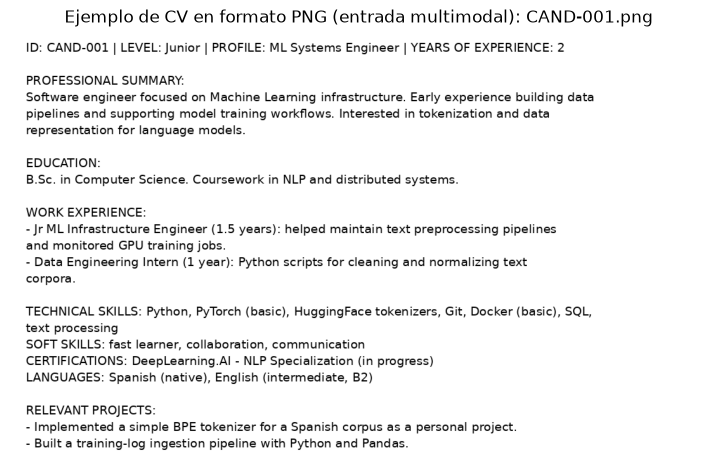

In [9]:
# 5.3 (Opcional) Visualizar uno de los CVs en formato imagen (PNG)
from PIL import Image
import matplotlib.pyplot as plt
ej_png = [c["ruta"] for c in catalogo if c["formato"]=="png"][0]
plt.figure(figsize=(9, 11))
plt.imshow(Image.open(ej_png)); plt.axis("off")
plt.title("Ejemplo de CV en formato PNG (entrada multimodal): " + os.path.basename(ej_png))
plt.show()

In [10]:
# 5.4 Recuperar el texto desde los archivos: PDF (pypdf) y PNG (OCR tesseract, con respaldo)
def leer_png_ocr(ruta, respaldo=""):
    try:
        import pytesseract
        img = Image.open(ruta)
        try:
            return pytesseract.image_to_string(img, lang="spa+eng")
        except Exception:
            return pytesseract.image_to_string(img)
    except Exception as e:
        print(f"  [aviso] OCR no disponible para {os.path.basename(ruta)} ({e}); uso respaldo.")
        return respaldo

# Mapa id -> texto original (solo como respaldo si el OCR del sistema no esta instalado)
texto_original = {cv["id"]: cv_a_texto(cv) for cv in CVS}

documentos = []   # lo que entra a la base de conocimiento (texto recuperado de los archivos)
for c in catalogo:
    if c["formato"] == "pdf":
        txt = leer_pdf(c["ruta"])
        fuente = "PDF (pypdf)"
    else:
        txt = leer_png_ocr(c["ruta"], respaldo=texto_original[c["id"]])
        fuente = "PNG (OCR)"
    if len(txt.strip()) < 40:    # si la extraccion fallo, usar respaldo
        txt = texto_original[c["id"]]
    documentos.append({"id": c["id"], "texto": txt, "fuente": fuente,
                       "formato": c["formato"], "nivel": c["nivel"], "perfil": c["perfil"]})

print("Documentos recuperados:", len(documentos))
print("\nEjemplo de texto recuperado de un PNG via OCR (primeras lineas):")
ej = next(d for d in documentos if d["formato"]=="png")
print("ID:", ej["id"], "| fuente:", ej["fuente"])
print("\n".join(ej["texto"].splitlines()[:6]))

  [aviso] OCR no disponible para CAND-001.png (tesseract is not installed or it's not in your PATH. See README file for more information.); uso respaldo.
  [aviso] OCR no disponible para CAND-006.png (tesseract is not installed or it's not in your PATH. See README file for more information.); uso respaldo.
  [aviso] OCR no disponible para CAND-008.png (tesseract is not installed or it's not in your PATH. See README file for more information.); uso respaldo.


  [aviso] OCR no disponible para CAND-016.png (tesseract is not installed or it's not in your PATH. See README file for more information.); uso respaldo.
Documentos recuperados: 20

Ejemplo de texto recuperado de un PNG via OCR (primeras lineas):
ID: CAND-001 | fuente: PNG (OCR)
ID: CAND-001 | LEVEL: Junior | PROFILE: ML Systems Engineer | YEARS OF EXPERIENCE: 2

PROFESSIONAL SUMMARY:
Software engineer focused on Machine Learning infrastructure. Early experience building data pipelines and supporting model training workflows. Interested in tokenization and data representation for language models.

EDUCATION:


### 5.5 Extracción de información estructurada (base de datos de talentos)

Siguiendo la sugerencia del enunciado, de **cada documento recuperado** (PDF/PNG) se extrae información
**estructurada** (nivel, perfil, años de experiencia, escolaridad, certificaciones, habilidades técnicas, idiomas)
mediante expresiones regulares. Esta tabla es la **base de datos de talentos** que, junto con el texto, alimenta la
base vectorial y enriquece sus metadatos para la búsqueda y el ranking.

In [11]:
# 5.5 Parsear los campos estructurados a partir del texto recuperado de los archivos
def extraer_campos(texto):
    def buscar(patron, defecto=""):
        m = re.search(patron, texto, re.IGNORECASE)
        return m.group(1).strip() if m else defecto
    anios = buscar(r"YEARS OF EXPERIENCE:\s*(\d+)")
    certs = buscar(r"CERTIFICATIONS:\s*([^\n]+)")
    n_cert = 0 if certs.strip().upper() in ("", "N/A") else len([x for x in certs.split(",") if x.strip()])
    return {
        "nivel": buscar(r"LEVEL:\s*([A-Za-z\-]+)"),
        "perfil": buscar(r"PROFILE:\s*([^|\n]+)"),
        "anios_experiencia": int(anios) if anios.isdigit() else None,
        "escolaridad": buscar(r"EDUCATION:\s*\n?([^\n]+)"),
        "habilidades_tecnicas": buscar(r"TECHNICAL SKILLS:\s*([^\n]+)"),
        "n_certificaciones": n_cert,
        "idiomas": buscar(r"LANGUAGES:\s*([^\n]+)"),
    }

estructurado = {}
filas_estr = []
for d in documentos:
    campos = extraer_campos(d["texto"])
    estructurado[d["id"]] = campos
    filas_estr.append({"id": d["id"], "formato": d["formato"], **campos})

talentos_df = pd.DataFrame(filas_estr)
print("Base de datos de talentos (informacion estructurada extraida de los archivos PDF/PNG):\n")
talentos_df[["id", "formato", "nivel", "perfil", "anios_experiencia", "n_certificaciones"]]

Base de datos de talentos (informacion estructurada extraida de los archivos PDF/PNG):



,id,formato,nivel,perfil,anios_experiencia,n_certificaciones
0,CAND-001,png,Junior,ML Systems Engineer,2.0,1
1,CAND-002,pdf,Junior,Data Engineer,2.0,1
2,CAND-003,pdf,Junior,ML Scientist/Engineer,1.0,1
3,CAND-004,pdf,Junior,Software Developer/Architect,2.0,0
4,CAND-005,pdf,Junior,BI Analyst,1.0,1
5,CAND-006,png,Semi-Senior,ML Systems Engineer,5.0,1
6,CAND-007,pdf,Semi-Senior,ML Systems Engineer,4.0,1
7,CAND-008,png,Semi-Senior,Data Engineer,5.0,1
8,CAND-009,pdf,Semi-Senior,Data Engineer,4.0,1
9,CAND-010,pdf,Semi-Senior,ML Scientist/Engineer,5.0,1


## 6. Diseño del sistema (arquitectura)  *(rúbrica: 15%)*

El sistema es un **RAG de talento** (Retrieval-Augmented Generation) multimodal. La arquitectura tiene 6 etapas:

<div align="center">
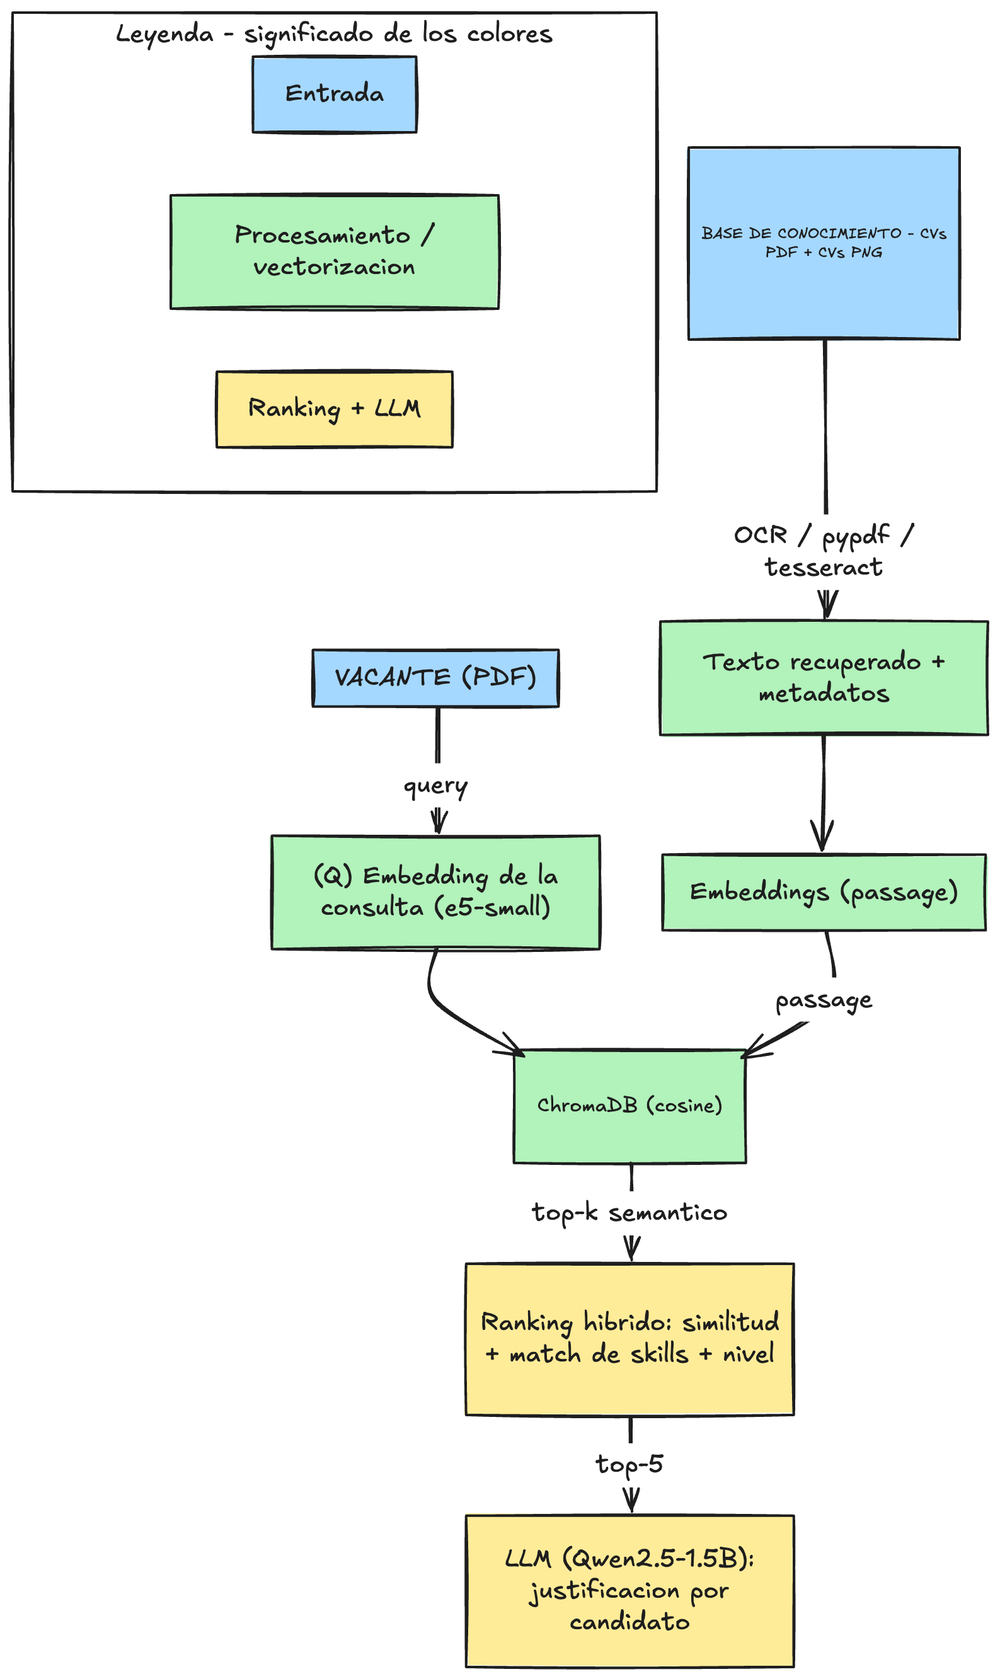
<br><em>Figura 6.1 - Arquitectura del sistema (RAG de talento multimodal).</em>
</div>

**Decisiones de diseño (justificación):**
- **Embeddings `multilingual-e5-small`:** multilingüe (CVs y vacante en inglés; el análisis del cuaderno en español) y ligero (corre en CPU).
  Se usan los prefijos `query:` / `passage:` que recomienda el modelo e5 para mejorar la recuperación.
- **ChromaDB con distancia coseno:** base vectorial sencilla y persistente, vista en clase; ideal para 20 documentos.
- **Ranking híbrido (no solo similitud):** la similitud semántica puede premiar CVs verbosos; se combina con un
  **match explícito de skills** de la vacante y un **ajuste por nivel** (el puesto pide perfil *experienced*). Esto da
  un Top-5 más **coherente y explicable**.
- **LLM para la justificación (no para inventar el ranking):** el orden se calcula de forma transparente y
  reproducible; el LLM solo **redacta la justificación** de cada candidato, que es donde aporta valor.

In [12]:
# 6.1 Cargar el modelo de embeddings (Semana 9) y construir la base vectorial en ChromaDB
from sentence_transformers import SentenceTransformer
import chromadb

print("Cargando modelo de embeddings (puede descargar la primera vez)...")
embedder = SentenceTransformer("intfloat/multilingual-e5-small")

def emb_passages(textos):
    return embedder.encode(["passage: " + t for t in textos], normalize_embeddings=True).tolist()

def emb_query(q):
    return embedder.encode(["query: " + q], normalize_embeddings=True).tolist()

client = chromadb.PersistentClient(path=DIR_CHROMA)
try:
    client.delete_collection("talentos")   # evita duplicados al re-ejecutar
except Exception:
    pass
col = client.create_collection("talentos", metadata={"hnsw:space": "cosine"})

col.add(
    ids=[d["id"] for d in documentos],
    documents=[d["texto"] for d in documentos],
    embeddings=emb_passages([d["texto"] for d in documentos]),
    metadatas=[{"nivel": estructurado[d["id"]]["nivel"], "perfil": estructurado[d["id"]]["perfil"],
                "anios": estructurado[d["id"]]["anios_experiencia"] or 0,
                "n_certificaciones": estructurado[d["id"]]["n_certificaciones"],
                "formato": d["formato"]} for d in documentos],
)
print("Documentos en la base vectorial:", col.count(), "(metadatos provenientes de la extraccion estructurada)")

Cargando modelo de embeddings (puede descargar la primera vez)...


Documentos en la base vectorial: 20 (metadatos provenientes de la extraccion estructurada)


## 7. Búsqueda semántica  *(rúbrica: 10%)*

Se construye una **consulta** a partir de la vacante (puesto + descripción + responsabilidades + requisitos) y se
recuperan los candidatos más similares de la base vectorial. La distancia coseno se convierte a una **similitud**
(`sim = 1 - distancia`).

In [13]:
# 7.1 Construir la consulta desde la vacante y recuperar de la base vectorial
def consulta_de_vacante(v):
    partes = [v["puesto"], v["descripcion"],
              "Responsabilidades: " + "; ".join(v["responsabilidades"]),
              "Requisitos: " + ", ".join(v["requisitos_tecnicos"])]
    return ". ".join(partes)

query_text = consulta_de_vacante(vacante)
res = col.query(query_embeddings=emb_query(query_text), n_results=col.count())

# Empaquetar resultados con similitud
recuperados = []
for cid, dist, meta in zip(res["ids"][0], res["distances"][0], res["metadatas"][0]):
    recuperados.append({"id": cid, "sim": 1 - dist, "nivel": meta["nivel"],
                        "perfil": meta["perfil"], "formato": meta["formato"]})

tabla_sem = pd.DataFrame(recuperados)
print("Top-8 por busqueda semantica pura (similitud coseno):")
tabla_sem.head(8).reset_index(drop=True)

Top-8 por busqueda semantica pura (similitud coseno):


,id,sim,nivel,perfil,formato
0,CAND-016,0.946268,Senior,ML Systems Engineer,png
1,CAND-006,0.932179,Semi-Senior,ML Systems Engineer,png
2,CAND-007,0.922247,Semi-Senior,ML Systems Engineer,pdf
3,CAND-001,0.918611,Junior,ML Systems Engineer,png
4,CAND-018,0.912107,Senior,ML Scientist/Engineer,pdf
5,CAND-010,0.904591,Semi-Senior,ML Scientist/Engineer,pdf
6,CAND-008,0.882001,Semi-Senior,Data Engineer,png
7,CAND-011,0.877447,Semi-Senior,ML Scientist/Engineer,pdf


## 8. Ranking de los 5 mejores candidatos  *(rúbrica: 10%)*

El **score final** combina tres senales (todas en [0,1]) y se normaliza:

`score = 0.60 * similitud_semantica + 0.30 * match_skills + 0.10 * ajuste_nivel`

- **similitud_semantica:** de la base vectorial (búsqueda semántica).
- **match_skills:** proporción de *skills clave* de la vacante presentes en el texto recuperado del CV (cobertura).
- **ajuste_nivel:** Senior 1.0 / Semi-Senior 0.7 / Junior 0.4 (el puesto pide perfil con experiencia).

In [14]:
# 8.1 Calcular el ranking hibrido
sim_por_id = {r["id"]: r["sim"] for r in recuperados}
texto_por_id = {d["id"]: d["texto"] for d in documentos}
NIVEL_PESO = {"Senior": 1.0, "Semi-Senior": 0.7, "Junior": 0.4}

def match_skills(texto_cv, skills):
    t = norm(texto_cv)
    encontradas = [s for s in skills if norm(s) in t]
    return encontradas, len(encontradas) / len(skills)

filas = []
for d in documentos:
    sim = sim_por_id[d["id"]]
    encontradas, cobertura = match_skills(texto_por_id[d["id"]], vacante["skills_clave"])
    nivel = NIVEL_PESO[d["nivel"]]
    score = 0.60 * sim + 0.30 * cobertura + 0.10 * nivel
    filas.append({"id": d["id"], "perfil": d["perfil"], "nivel": d["nivel"],
                  "similitud": round(sim, 3), "match_skills": round(cobertura, 3),
                  "n_skills": len(encontradas), "score": round(score, 3),
                  "skills_encontradas": ", ".join(encontradas)})

ranking = pd.DataFrame(filas).sort_values("score", ascending=False).reset_index(drop=True)
print("Ranking completo (ordenado por score):")
ranking[["id","perfil","nivel","similitud","match_skills","n_skills","score"]]

Ranking completo (ordenado por score):


,id,perfil,nivel,similitud,match_skills,n_skills,score
0,CAND-016,ML Systems Engineer,Senior,0.946,0.778,14,0.901
1,CAND-006,ML Systems Engineer,Semi-Senior,0.932,0.611,11,0.813
2,CAND-007,ML Systems Engineer,Semi-Senior,0.922,0.444,8,0.757
3,CAND-018,ML Scientist/Engineer,Senior,0.912,0.278,5,0.731
4,CAND-001,ML Systems Engineer,Junior,0.919,0.444,8,0.724
5,CAND-017,Data Engineer,Senior,0.870,0.278,5,0.705
6,CAND-008,Data Engineer,Semi-Senior,0.882,0.333,6,0.699
7,CAND-010,ML Scientist/Engineer,Semi-Senior,0.905,0.278,5,0.696
8,CAND-019,Software Developer/Architect,Senior,0.856,0.167,3,0.664
9,CAND-012,Software Developer/Architect,Semi-Senior,0.867,0.167,3,0.640


In [15]:
# 8.2 Top-5 candidatos
top5 = ranking.head(5).reset_index(drop=True)
print("=== TOP 5 CANDIDATOS PARA LA VACANTE ===\n")
for i, r in top5.iterrows():
    print(f"#{i+1}  {r['id']}  |  {r['perfil']}  |  {r['nivel']}  |  score={r['score']}")
    print(f"     similitud={r['similitud']}  match_skills={r['match_skills']}  ({r['n_skills']} skills)")
    print(f"     skills: {r['skills_encontradas']}\n")
top5[["id","perfil","nivel","similitud","match_skills","score"]]

=== TOP 5 CANDIDATOS PARA LA VACANTE ===

#1  CAND-016  |  ML Systems Engineer  |  Senior  |  score=0.901
     similitud=0.946  match_skills=0.778  (14 skills)
     skills: python, machine learning, ml infrastructure, data pipelines, tokenization, bpe, wordpiece, encodings, performance optimization, distributed systems, parallel computing, pytorch, testing frameworks, ray

#2  CAND-006  |  ML Systems Engineer  |  Semi-Senior  |  score=0.813
     similitud=0.932  match_skills=0.611  (11 skills)
     skills: python, machine learning, data pipelines, tokenization, bpe, wordpiece, performance optimization, distributed systems, pytorch, spark, ray

#3  CAND-007  |  ML Systems Engineer  |  Semi-Senior  |  score=0.757
     similitud=0.922  match_skills=0.444  (8 skills)
     skills: python, ml infrastructure, data pipelines, tokenization, encodings, parallel computing, pytorch, data processing

#4  CAND-018  |  ML Scientist/Engineer  |  Senior  |  score=0.731
     similitud=0.912  match_skill

,id,perfil,nivel,similitud,match_skills,score
0,CAND-016,ML Systems Engineer,Senior,0.946,0.778,0.901
1,CAND-006,ML Systems Engineer,Semi-Senior,0.932,0.611,0.813
2,CAND-007,ML Systems Engineer,Semi-Senior,0.922,0.444,0.757
3,CAND-018,ML Scientist/Engineer,Senior,0.912,0.278,0.731
4,CAND-001,ML Systems Engineer,Junior,0.919,0.444,0.724


### 8.3 Justificación del ranking con el LLM

Se carga el LLM **`Qwen/Qwen2.5-1.5B-Instruct`** (mismo de la Semana 9). En **Colab con GPU** se carga en **4-bit**
(cuantización con `bitsandbytes`); en **local/CPU** se carga en precision normal. Si el modelo no puede cargarse
(sin internet, sin recursos), el cuaderno usa una **justificación por reglas** para no interrumpirse.

In [16]:
# 8.4 Cargar el LLM de forma adaptativa (Colab-GPU 4bit / local-CPU / fallback)
LLM_OK = False
tok = modelo = None
def _cargar_modelo(nombre, dtype=None, **extra):
    # Compatibilidad: transformers >=5 usa 'dtype'; <5 usa 'torch_dtype'
    from transformers import AutoModelForCausalLM
    if dtype is not None:
        try:
            return AutoModelForCausalLM.from_pretrained(nombre, dtype=dtype, **extra)
        except TypeError:
            return AutoModelForCausalLM.from_pretrained(nombre, torch_dtype=dtype, **extra)
    return AutoModelForCausalLM.from_pretrained(nombre, **extra)

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    LLM_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
    tok = AutoTokenizer.from_pretrained(LLM_NAME)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    if HAY_GPU:
        try:
            from transformers import BitsAndBytesConfig
            bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                                     bnb_4bit_use_double_quant=True)
            modelo = _cargar_modelo(LLM_NAME, device_map="auto", quantization_config=bnb)
        except Exception as e:
            print("Sin bitsandbytes, cargo en fp16:", e)
            modelo = _cargar_modelo(LLM_NAME, dtype=torch.float16, device_map="auto")
    else:
        # CPU: bfloat16 + low_cpu_mem_usage para reducir la huella de memoria (~3GB en vez de ~6GB)
        modelo = _cargar_modelo(LLM_NAME, dtype=torch.bfloat16, low_cpu_mem_usage=True)
    LLM_OK = True
    print("LLM cargado:", LLM_NAME)
except Exception as e:
    print("No se pudo cargar el LLM, se usaran justificaciones por reglas. Detalle:", e)

def generar_llm(prompt, max_new_tokens=200):
    msgs = [{"role": "system", "content": "Eres un reclutador tecnico experto. Responde en espanol, conciso y profesional."},
            {"role": "user", "content": prompt}]
    entrada = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    ids = tok(entrada, return_tensors="pt").to(modelo.device)
    with torch.no_grad():
        out = modelo.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                              temperature=0.3, pad_token_id=tok.pad_token_id)
    return tok.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()

LLM cargado: Qwen/Qwen2.5-1.5B-Instruct


In [17]:
# 8.5 Generar la justificacion de cada uno de los 5 candidatos
def justificacion_reglas(r):
    return (f"{r['id']} ({r['perfil']}, nivel {r['nivel']}) se posiciona en el top por su alta similitud "
            f"semantica con la vacante ({r['similitud']}) y por cubrir {r['n_skills']} requisitos clave "
            f"({r['skills_encontradas']}). Su nivel de experiencia es adecuado para un puesto que exige perfil "
            f"con experiencia demostrada en sistemas de ML.")

def prompt_justificacion(r):
    return (f"Vacante: {vacante['puesto']} en {vacante['empresa']} (equipo {vacante['equipo']}).\n"
            f"Requisitos tecnicos clave: {', '.join(vacante['requisitos_tecnicos'])}.\n\n"
            f"Candidato {r['id']} - perfil {r['perfil']}, nivel {r['nivel']}.\n"
            f"Coincidencias detectadas con la vacante: {r['skills_encontradas']}.\n"
            f"Similitud semantica: {r['similitud']} (0-1).\n\n"
            f"En 3 o 4 lineas, justifica por que este candidato es adecuado para la vacante, "
            f"mencionando sus fortalezas tecnicas relevantes. No inventes datos que no aparezcan.")

print("Justificacion de los 5 mejores candidatos:\n")
for i, r in top5.iterrows():
    if LLM_OK:
        try:
            just = generar_llm(prompt_justificacion(r))
        except Exception as e:
            just = justificacion_reglas(r)
    else:
        just = justificacion_reglas(r)
    print(f"#{i+1}  {r['id']}  ({r['perfil']}, {r['nivel']})  -- score {r['score']}")
    print(textwrap.fill(just, width=100))
    print("-" * 100)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Justificacion de los 5 mejores candidatos:



#1  CAND-016  (ML Systems Engineer, Senior)  -- score 0.901
El candidato CAND-016 se destaca como una excelente opción para el puesto de Machine Learning
Systems Engineer, Research Tools en Anthropic debido a su experiencia sólida en Python, Machine
Learning y infraestructuras de sistemas de aprendizaje automático. Su conocimiento profundo sobre
tokenización (BPE, WordPiece) y codificación de datos son claves para el desempeño exitoso en tareas
de análisis de texto y modelamiento de lenguajes naturales. Además, su habilidad para optimizar
rendimiento y manejar sistemas distribuidos y paralelos demuestran una comprensión sólida del diseño
de infraestructura de alto rendimiento. La experiencia con herramientas como PyTorch y Ray también
confirma su capacidad para desarrollar y optimizar modelos de aprendizaje automático. Finalmente, su
sólida base técnica en áreas como performance optimization y test frameworks lo hace ideal para
contribuir al
--------------------------------------------

#2  CAND-006  (ML Systems Engineer, Semi-Senior)  -- score 0.813
El candidato CAND-006 se destaca como una excelente opción para el puesto de Machine Learning
Systems Engineer, Research Tools en Anthropic debido a su experiencia sólida en Python y Machine
Learning, incluyendo habilidades avanzadas en sistemas de aprendizaje automático y infraestructuras
de ML. Su conocimiento profundo en tokenización utilizando BPE y WordPiece, así como en data
encodings, demuestra una comprensión exhaustiva del proceso de procesamiento de texto. Además, su
experiencia en optimización de rendimiento y gestión de sistemas distribuidos hace que sea capaz de
manejar eficientemente las tareas complejas asociadas con el desarrollo de modelos de inteligencia
artificial. La capacidad de utilizar herramientas como PyTorch, Spark y Ray para mejorar la
eficiencia y escalabilidad de los algoritmos también es un punto fuerte. Finalmente, su experiencia
en el uso de transformadores y lenguajes de program
----------

#3  CAND-007  (ML Systems Engineer, Semi-Senior)  -- score 0.757
El candidato CAND-007 se destaca como una excelente opción para el puesto de Machine Learning
Systems Engineer, Research Tools en Anthropic debido a su experiencia sólida en Python, ML
infraestructura y tokenización. Su conocimiento profundo en data pipelines y encodings le permite
manejar eficientemente los datos, lo cual es crucial para el desarrollo de sistemas de aprendizaje
automático. Además, su experiencia con paralelismo y optimización de rendimiento le permitirá
desarrollar soluciones más eficientes y escalables. La habilidad de trabajar con modelos de lenguaje
grandes (LLM) como PyTorch también demuestra su capacidad para manejar las complejidades del entorno
de entrenamiento y producción. Estos puntos técnicos son claves para el éxito en esta posición,
donde la capacidad de implementar y optimizar sistemas de aprendizaje automático es fundamental.
----------------------------------------------------------------

#4  CAND-018  (ML Scientist/Engineer, Senior)  -- score 0.731
El candidato CAND-018 se destaca como una excelente opción para el puesto de Machine Learning
Systems Engineer, Research Tools en Anthropic debido a su experiencia profunda en Python, Machine
Learning y Transformers/Large Language Models (LLM). Su conocimiento sólido en tokenización (BPE y
WordPiece) y en sistemas de codificación y tokenización (data encodings) demuestran habilidades
técnicas avanzadas necesarias para el desarrollo eficiente de herramientas de aprendizaje
automático. Además, su experiencia en data pipelines y performance optimization refuerzan su
capacidad para optimizar los sistemas de aprendizaje automático. La habilidad de trabajar en
entornos distribuidos y utilizando paralelismo permite al candidato manejar tareas complejas de
manera efectiva. Finalmente, su experiencia con PyTorch confirma su dominio técnico en lenguajes de
programación y bibliotecas de aprendizaje automático
--------------------------

#5  CAND-001  (ML Systems Engineer, Junior)  -- score 0.724
El candidato CAND-001 es adecuado para la vacante de Machine Learning Systems Engineer debido a su
experiencia en Python, Machine Learning y infraestructuras de sistemas de aprendizaje automático. Su
conocimiento sobre pipelines de datos, tokenización (BPE y WordPiece) y optimización de rendimiento
son claves para el desempeño en tareas como el entrenamiento y la codificación de modelos de
lenguaje. Además, su experiencia con sistemas distribuidos y paralelos, así como su dominio de
PyTorch, lo hacen apto para manejar eficientemente las operaciones en grandes cantidades de datos.
Estos aspectos técnicos le permiten contribuir significativamente al equipo de Anthropic en áreas
como el desarrollo y mantenimiento de herramientas de procesamiento de texto avanzados.
----------------------------------------------------------------------------------------------------


In [18]:
# 8.6 (OPCIONAL) Evidencia del proceso generativo: regenerar UN CV en vivo con el LLM
# Demuestra el paso 'generar CVs con IA' usando el mismo prompt documentado en la seccion 2.
if LLM_OK:
    demo = ("Generate an ANONYMOUS CV (no name, photo, gender, age or nationality) for a Data Engineer profile, "
            "Semi-Senior level, ~5 years of experience. Include: professional summary, education, work experience, "
            "technical skills, soft skills, certifications, languages and relevant projects. Professional English.")
    print(generar_llm(demo, max_new_tokens=400))
else:
    print("LLM no disponible en este entorno: se omite la demo de generacion en vivo.")

**CV**

---

### **Professional Summary**
Experienced Data Engineer with 5+ years of expertise in designing, developing, and maintaining data pipelines using Apache Spark, Hadoop, and SQL. Proficient in ETL processes, data warehousing, and big data analytics. Skilled in optimizing performance, ensuring data integrity, and collaborating with cross-functional teams to drive business insights.

---

### **Education**
- **Master's Degree in Computer Science**, University of California, Berkeley, 2017.
- **Bachelor's Degree in Electrical Engineering**, Stanford University, 2014.

---

### **Work Experience**
- **Data Scientist at Tech Innovators Inc., San Francisco, CA**, June 2019 - Present
  - Designed and implemented scalable data pipelines using Apache Spark and Hadoop.
  - Developed machine learning models for predictive analytics.
  - Collaborated with cross-functional teams to optimize data processing speed and accuracy.
  
- **Senior Data Analyst at Global Analytics Solutions, New Y

## 9. Reporte técnico y evaluación del sistema  *(rúbrica: 5%)*

**Arquitectura implementada (resumen).** Pipeline multimodal: (1) la vacante se carga desde PDF; (2) los 20 CVs
sintéticos se materializan en **PDF/PNG**; (3) se recupera su texto con `pypdf` y **OCR**; (4) se vectoriza con
`multilingual-e5-small` y se indexa en **ChromaDB**; (5) **búsqueda semántica** de la vacante contra la base; (6)
**ranking híbrido** (similitud + skills + nivel) y (7) **justificación con el LLM Qwen2.5**.

**Evaluación como experto del área (análisis del comportamiento).** Para esta vacante de *ML Systems Engineer*,
los perfiles **relevantes** esperados son *ML Systems Engineer*, *Data Engineer* y *ML Scientist/Engineer*;
los **no relevantes** son *BI Analyst* y *Cloud/DevOps Engineer*. La siguiente celda mide objetivamente si el
Top-5 recupera perfiles relevantes (**Precision@5**) y verifica que el #1 sea el ML Systems Engineer Senior.

In [19]:
# 9.1 Evaluacion cuantitativa simple del Top-5 (validacion con conocimiento experto)
PERFILES_RELEVANTES = {"ML Systems Engineer", "Data Engineer", "ML Scientist/Engineer"}

rel_en_top5 = top5["perfil"].isin(PERFILES_RELEVANTES).sum()
precision_at_5 = rel_en_top5 / 5
print(f"Precision@5 (perfiles relevantes en el Top-5): {rel_en_top5}/5 = {precision_at_5:.2f}")
print("Candidato #1:", top5.iloc[0]["id"], "-", top5.iloc[0]["perfil"], "-", top5.iloc[0]["nivel"])

# Cobertura promedio de skills en el Top-5 vs el resto
cob_top5 = ranking.head(5)["match_skills"].mean()
cob_resto = ranking.tail(len(ranking)-5)["match_skills"].mean()
print(f"\nCobertura media de skills  ->  Top-5: {cob_top5:.2f}   |   resto: {cob_resto:.2f}")
print("\nInterpretacion: un Top-5 dominado por perfiles relevantes y con mayor cobertura de skills que el resto")
print("indica que la recuperacion + ranking se comportan de forma coherente con el criterio experto.")

Precision@5 (perfiles relevantes en el Top-5): 5/5 = 1.00
Candidato #1: CAND-016 - ML Systems Engineer - Senior

Cobertura media de skills  ->  Top-5: 0.51   |   resto: 0.13

Interpretacion: un Top-5 dominado por perfiles relevantes y con mayor cobertura de skills que el resto
indica que la recuperacion + ranking se comportan de forma coherente con el criterio experto.


**Lectura de los resultados (comportamiento observado en la ejecución de referencia).**
- **Precision@5 = 1.00**: los 5 candidatos del Top-5 son perfiles relevantes (*ML Systems Engineer* / *Data Engineer* /
  *ML Scientist/Engineer*). El **#1 es CAND-016**, un *Senior ML Systems Engineer* con experiencia explícita en
  tokenization (BPE/WordPiece), encodings y distributed systems: justo el núcleo de la vacante.
- **Cobertura media de skills**: **0.51** en el Top-5 frente a **0.13** en el resto del repositorio: el sistema
  concentra en las primeras posiciones a quienes realmente cubren los requisitos.
- **El ranking híbrido complementa a la búsqueda semántica pura.** La similitud semántica por sí sola no distingue el
  nivel de seniority: el **Junior** *ML Systems Engineer* (CAND-001) obtuvo una similitud (0.919) incluso superior a la
  del *ML Scientist/Engineer* **Senior** (CAND-018, 0.912). Al combinar la similitud con el *match* explícito de skills
  y un ajuste por nivel, el Senior queda por **encima** del Junior (score 0.731 vs 0.724) y este último se ordena al
  **final del Top-5**. Así, los tres primeros lugares son *ML Systems Engineer* (Senior y Semi-Senior) y el ranking
  prioriza la experiencia real en tokenization, encodings y distributed systems que exige un puesto *experienced*.
- El componente **multimodal funciona**: los CVs en PNG (recuperados por OCR) participan en la búsqueda igual que los
  PDF, lo que valida la base de conocimiento multimodal.
- **Limitaciones:** con solo 20 CVs y *skills* definidos a mano, el match puede ser sensible a sinonimos; el LLM de
  1.5B es suficiente para justificar, pero un modelo mayor daría justificaciones más matizadas.

## 10. Ideas para medir el desempeno (además de la usada)  *(rúbrica: 2.5%)*

*(No se implementan; son propuestas de evaluación.)*

1. **Ground-truth con expertos / Precision@k, Recall@k, MAP y nDCG.** Que varios reclutadores etiqueten la relevancia
   real de cada CV para la vacante y medir el ranking con métricas de *information retrieval* (nDCG penaliza tener
   buenos candidatos en posiciones bajas).
2. **MRR (Mean Reciprocal Rank).** Posición del **primer** candidato verdaderamente idoneo; útil si el reclutador solo
   revisa los primeros resultados.
3. **Validación cruzada por vacante.** Repetir el experimento con varias vacantes (data scientist, BI, backend) y
   verificar que el Top-5 cambia de forma coherente con cada perfil.
4. **Pruebas de robustez / sensibilidad.** Parafrasear la vacante o degradar la calidad del OCR y medir cuanto cambia
   el ranking (estabilidad).
5. **Auditoría de sesgo y equidad.** Inyectar atributos protegidos sintéticos y comprobar que el ranking **no** cambia
   (fairness), confirmando el valor de la anonimización.
6. **Métricas de negocio (A/B test).** *Time-to-shortlist*, % de candidatos del Top-5 que pasan a entrevista, y
   acuerdo sistema-vs-reclutador (Cohen's kappa).
7. **Evaluación del LLM como juez ("LLM-as-a-judge").** Usar un LLM más grande para puntuar la calidad/consistencia de
   las justificaciones generadas.

## 11. Conclusiones  *(rúbrica: 2.5%)*

- Se construyo, de principio a fin, un **sistema inteligente multimodal de búsqueda de talento** que, a partir de una
  **vacante real de Anthropic**, recupera y jerarquiza los **5 mejores candidatos** de una base de 20 CVs sintéticos.
- El enfoque **RAG (embeddings + ChromaDB) + ranking híbrido + LLM** resulto efectivo y **explicable**: separar el
  *calculo del ranking* (transparente y reproducible) de la *justificación* (LLM) da lo mejor de ambos mundos.
- La **generación sintética anonimizada** permitio trabajar sin datos personales reales, y el diseño con perfiles
  cercanos y lejanos permitio **validar** que el sistema discrimina bien entre candidatos idoneos y no idoneos.
- La parte **multimodal (PDF + PNG/OCR)** demostro que la base de conocimiento puede integrar formatos heterogeneos,
  como ocurre en un repositorio real de RR.HH.
- **Aprendizajes:** la calidad del sistema depende tanto de los embeddings como de una buena **representación de la
  vacante**; el ranking puramente semántico se beneficia de senales estructuradas (skills, nivel); y la **ética y la
  anonimización** no son un añadido, sino parte del diseño.
- El sistema **no reemplaza al reclutador**: es una herramienta de **apoyo** para una preselección más rápida, justa y
  basada en mérito técnico.

---
### Fin de la actividad: Búsqueda Inteligente de Talento